Проверка генерации картинок

In [1]:
import pandas as pd
import numpy as np
import wfdb
import ast
from os.path import join 
import cv2

import matplotlib.pyplot as plt
import ecg_plot

%matplotlib inline

Тесты

In [46]:
# record_name = 'my_ecg_record'
record_name = 'examples/wfdb_87'
data = wfdb.rdsamp(record_name)

In [47]:
data

(array([[ 9.57340378, 13.24698263,  0.        , ...,  1.34198964,
          0.        ,  1.34890845],
        [ 8.08992179, 12.51103915,  0.        , ...,  1.34198964,
          0.        ,  1.34890845],
        [ 4.41088645, 12.51103915,  0.        , ...,  1.68281241,
          0.33550508,  1.34890845],
        ...,
        [ 0.        ,  0.        ,  0.        , ...,  0.        ,
          0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        , ...,  0.        ,
          0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        , ...,  0.        ,
          0.        ,  0.        ]]),
 {'fs': 500,
  'sig_len': 1482,
  'n_sig': 12,
  'base_date': None,
  'base_time': None,
  'units': ['mV',
   'mV',
   'mV',
   'mV',
   'mV',
   'mV',
   'mV',
   'mV',
   'mV',
   'mV',
   'mV',
   'mV'],
  'sig_name': ['I',
   'II',
   'III',
   'aVR',
   'aVL',
   'aVF',
   'V1',
   'V2',
   'V3',
   'V4',
   'V5',
   'V6'],
  'comments': []})

In [43]:
# сравнение с wfdb
ptb_name = 'examples/00002_lr'
ptb_data = wfdb.rdsamp(ptb_name)
ptb_data

(array([[ 0.004,  0.138,  0.134, ...,  0.192,  0.083,  0.088],
        [-0.02 ,  0.116,  0.136, ...,  0.156,  0.057,  0.063],
        [-0.053,  0.092,  0.145, ...,  0.107,  0.013,  0.022],
        ...,
        [ 0.121,  0.398,  0.277, ..., -1.065, -0.492, -0.156],
        [-0.326,  0.057,  0.383, ..., -0.28 , -0.175, -0.071],
        [-0.348, -0.056,  0.292, ..., -0.308, -0.231, -0.145]]),
 {'fs': 100,
  'sig_len': 1000,
  'n_sig': 12,
  'base_date': None,
  'base_time': None,
  'units': ['mV',
   'mV',
   'mV',
   'mV',
   'mV',
   'mV',
   'mV',
   'mV',
   'mV',
   'mV',
   'mV',
   'mV'],
  'sig_name': ['I',
   'II',
   'III',
   'AVR',
   'AVL',
   'AVF',
   'V1',
   'V2',
   'V3',
   'V4',
   'V5',
   'V6'],
  'comments': []})

TypeError: unsupported operand type(s) for +: 'dict' and 'float'

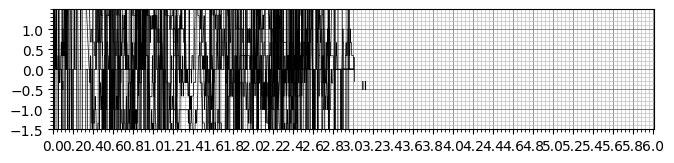

In [31]:
sample_rate = 500

ecg_plot.plot(data, sample_rate=sample_rate, title="", style="bw")
ecg_plot.show()

TypeError: unsupported operand type(s) for +: 'dict' and 'float'

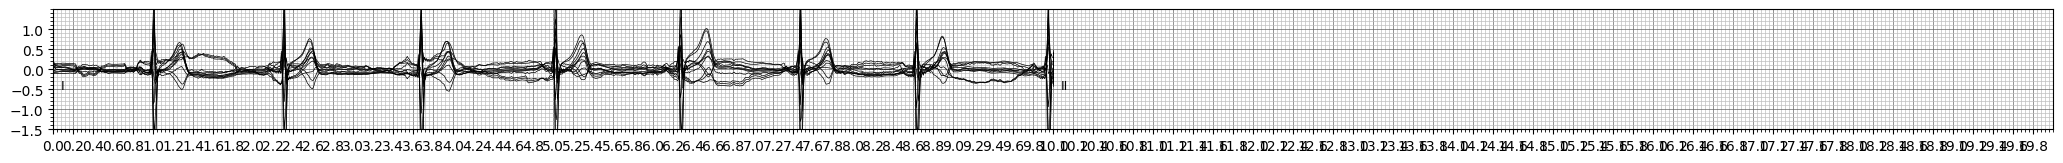

In [39]:
sample_rate = 100

ecg_plot.plot(ptb_data, sample_rate=sample_rate, title="", style="bw")
ecg_plot.show()

Ещё тесты

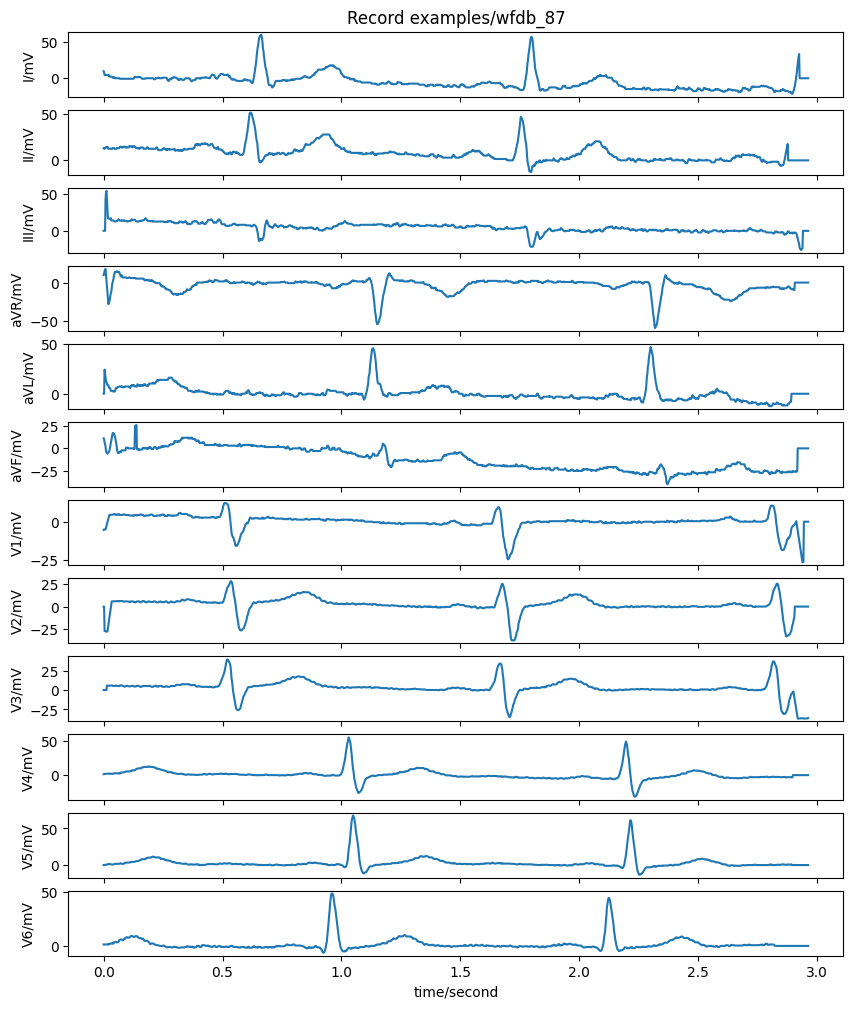

In [48]:
record = wfdb.rdrecord(record_name)
annotation = None

wfdb.plot_wfdb(record=record, annotation=annotation,
               title=f'Record {record_name}',
               time_units='seconds', figsize=(10, 12))

plt.show()


## Загрузка PTB-XL

In [2]:
def load_raw_data(df, sampling_rate, path):
    if sampling_rate == 100:
        data = [wfdb.rdsamp(join(path, f)) for f in df.filename_lr]
    else:
        data = [wfdb.rdsamp(join(path, f)) for f in df.filename_hr]
    data = np.array([signal for signal, meta in data])
    return data

In [3]:
PTB_PATH = r'/home/semyon/ecg/physionet.org/files/ptb-xl/1.0.3'
SAMPLING_RATE=100

# load and convert annotation data
Y = pd.read_csv(join(PTB_PATH, 'ptbxl_database.csv'), index_col='ecg_id')
Y.scp_codes = Y.scp_codes.apply(lambda x: ast.literal_eval(x))

# Load raw signal data 
# первые 100
X = load_raw_data(Y[:100], SAMPLING_RATE, PTB_PATH)

In [4]:
X.shape

(100, 1000, 12)

## Генерация

Как использовать lead_index?

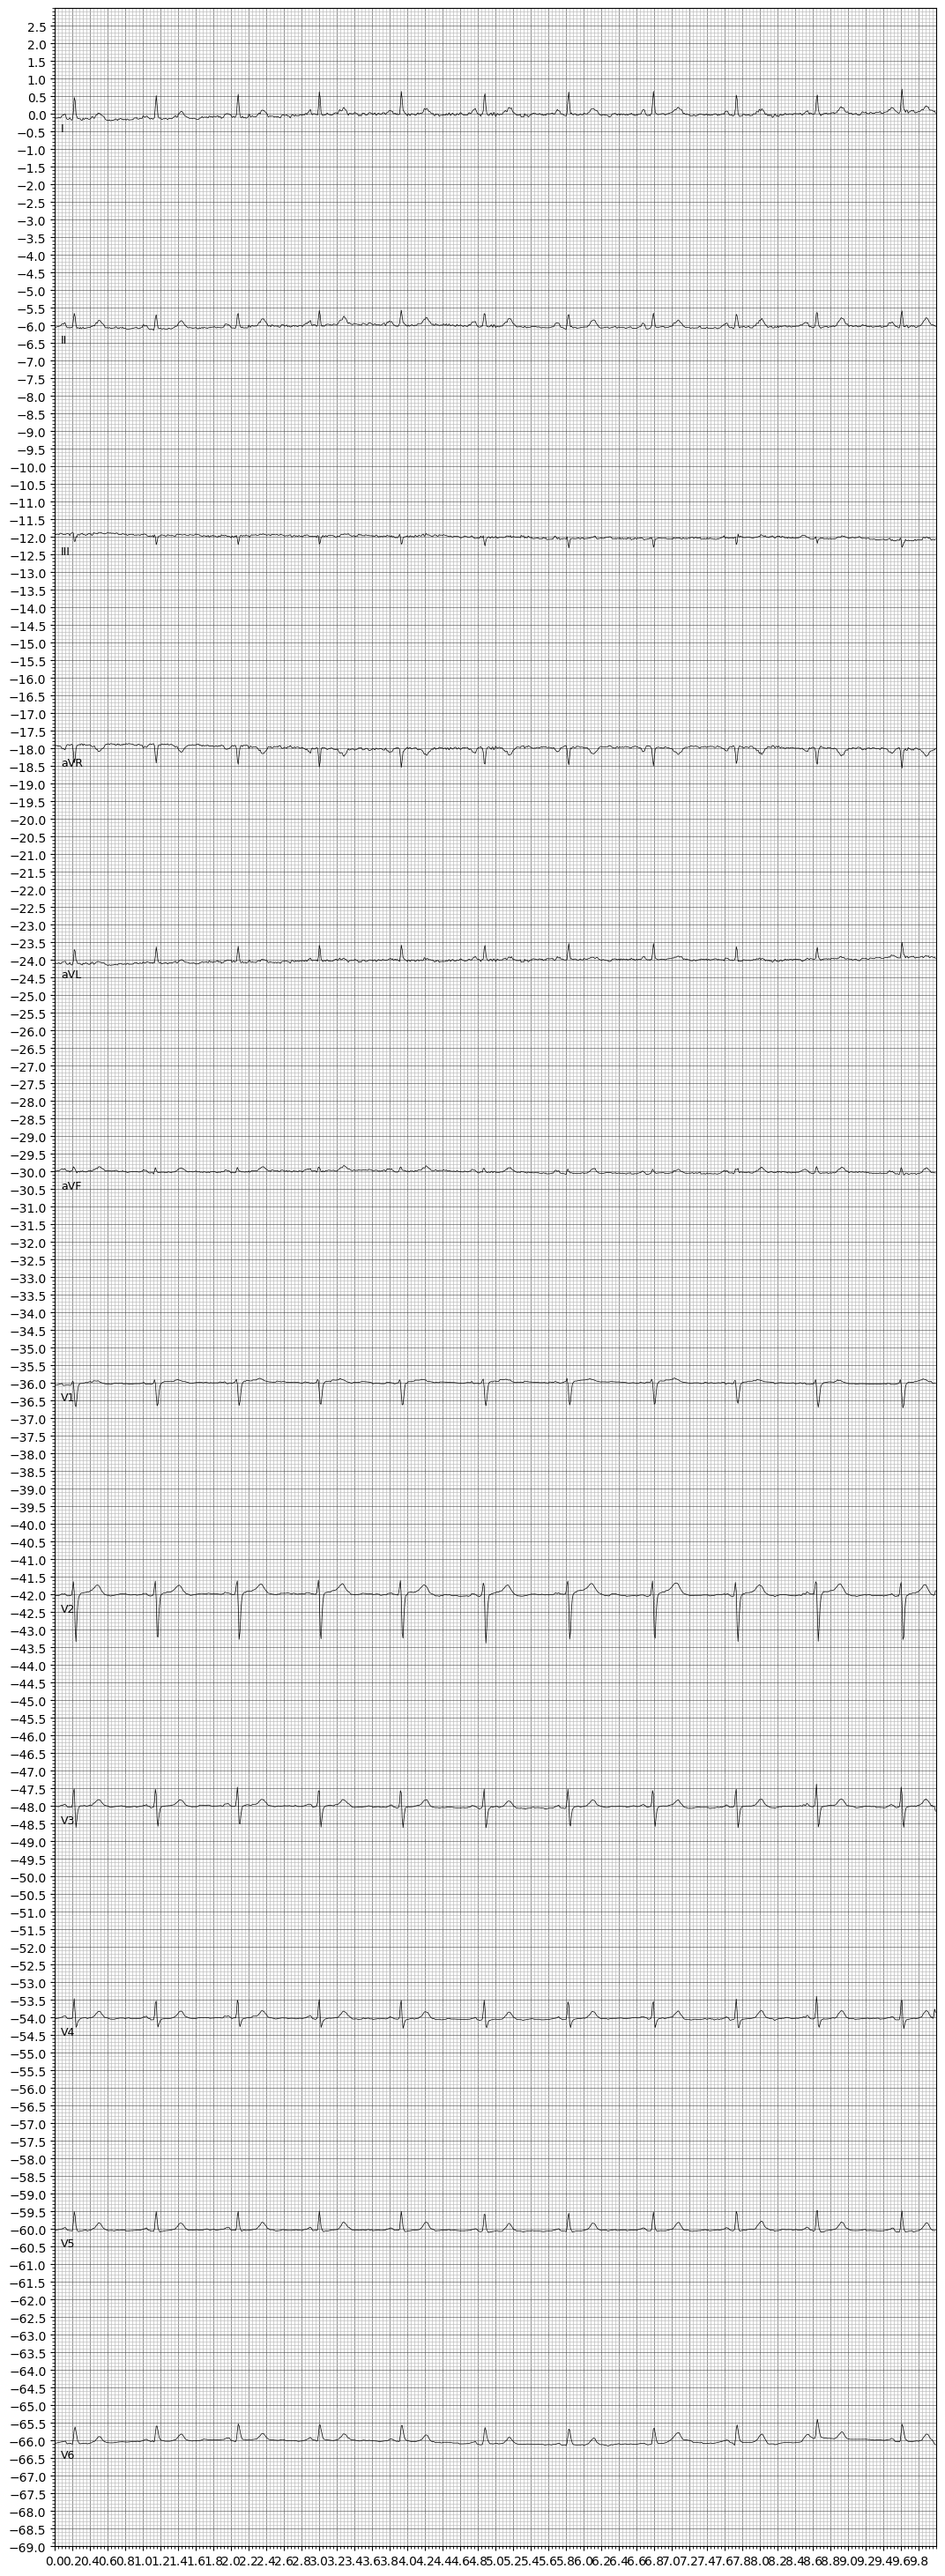

In [23]:
PNG_FILENAME = 'first.png'

sample = X[0]
sample_rate = 100
title=PNG_FILENAME.split(".")[0]

ecg_plot.plot(np.transpose(sample), sample_rate=sample_rate, columns=1, row_height=12, title="", style="bw")
ecg_plot.show()

ecg        : m x n ECG signal data, which m is number of leads and n is length of signal.

In [31]:
np.transpose(sample).shape

(12, 1000)

In [34]:
len(np.transpose(sample))/sample_rate

0.12

In [27]:
len(X[0])

1000